# **CNN (Convolutional Neural Network)**

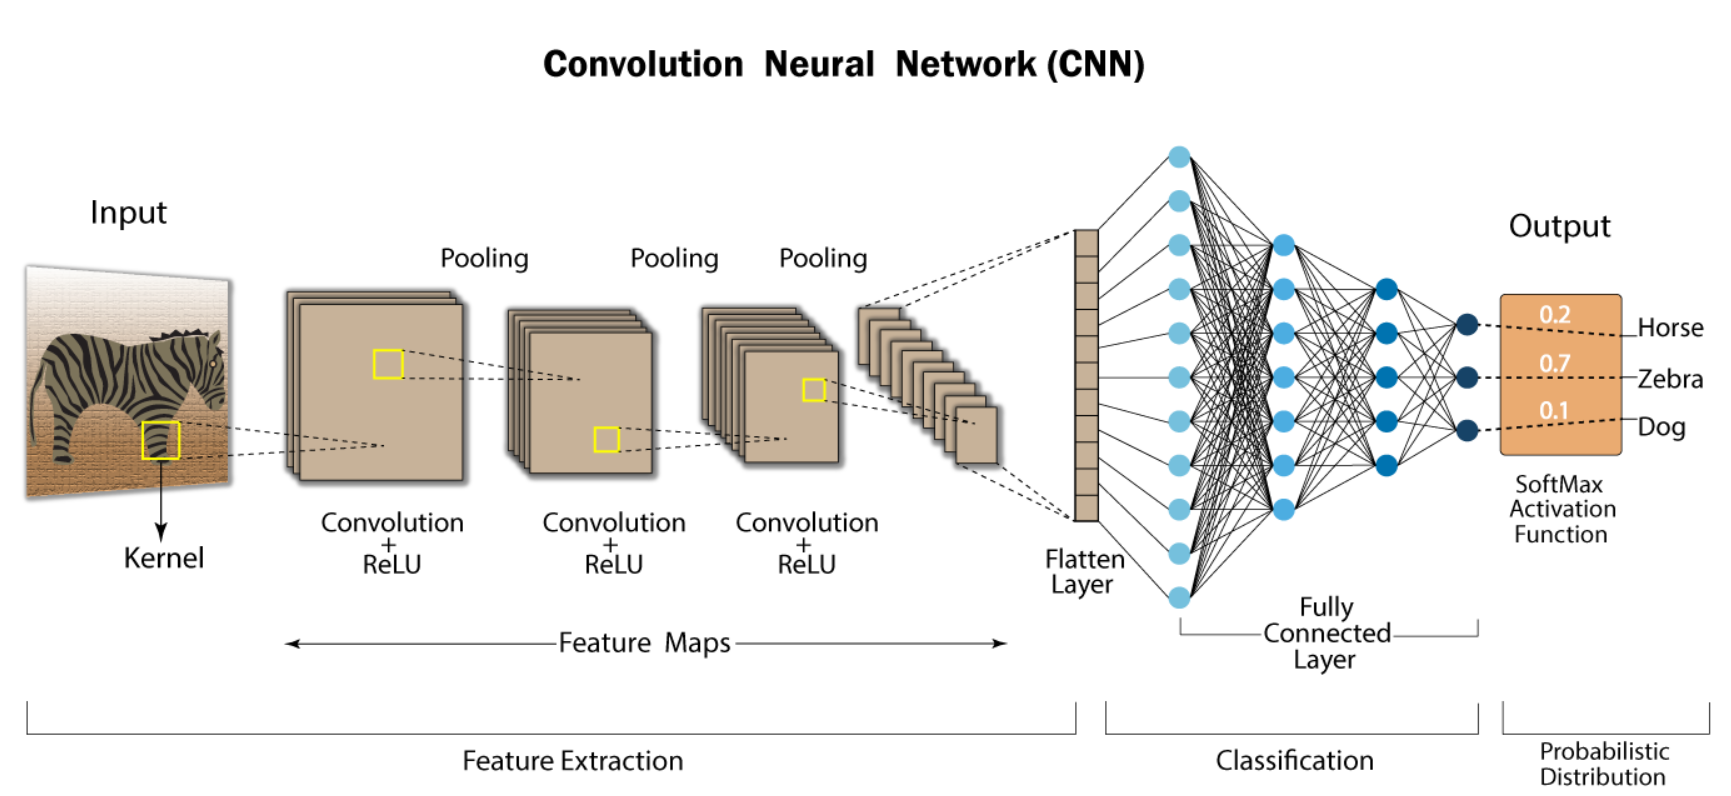

Why Cant use ANN on image classification
- High Computational Cost
- Overfitting
- Loss of imp info like spatial agreement of pixels

# Why Standard ANNs Struggle with Image Classification

While you *can* technically use a standard Artificial Neural Network (ANN) — also known as a **Multilayer Perceptron (MLP)** — for image classification, it is highly inefficient and performs poorly compared to Convolutional Neural Networks (CNNs). 

Here is a breakdown of the major reasons why standard ANNs are not suited for image data:

## 1. The Curse of Dimensionality (Explosion of Parameters)
Standard ANNs use **Fully Connected (Dense) layers**, meaning every neuron in one layer connects to every neuron in the next layer. 

Images are 3D tensors (Width $\times$ Height $\times$ Channels). Before feeding an image into an ANN, you must flatten it into a 1D vector. This causes the number of trainable weights to skyrocket.

### Example Math:
* Consider a relatively small color image of size **$200 \times 200$ pixels** with 3 color channels (RGB).
* Flattening this image results in an input vector of:
    $$200 \times 200 \times 3 = 120,000 \text{ inputs}$$
* If your very first hidden layer has just **1,000 neurons**, the number of weight connections for just that single layer is:
    $$120,000 \times 1,000 = 120,000,000 \text{ weights}$$

Managing **120 million weights** for a single, small layer leads to massive memory consumption, slow training times, and a severe risk of **overfitting**.

## 2. Loss of Spatial and Structural Information
Images possess **spatial topology**. A pixel's meaning is heavily dependent on its neighboring pixels (e.g., a group of nearby pixels forms an edge, a corner, or a texture).

When you flatten an image into a 1D vector to feed it into an ANN, you completely destroy this 2D/3D spatial relationship. The network treats pixels that were originally next to each other no differently than pixels on opposite sides of the image.



## 3. Lack of Translation Invariance
Standard ANNs are not translation invariant. This means if a network learns to recognize a cat in the **top-left corner** of an image, it will completely fail to recognize the exact same cat if it appears in the **bottom-right corner**. 

Because ANNs look at global pixel positions rather than local features, you would need to train the network on every object at every single possible pixel location, which is practically impossible.

## 4. Inability to Extract Hierarchical Features
Visual data is inherently hierarchical. Human vision and advanced neural networks understand images by building up complexity:
1.  **Low-level features:** Edges, lines, and gradients.
2.  **Mid-level features:** Corners, textures, and shapes (eyes, wheels).
3.  **High-level features:** Complete objects (faces, cars).

Because ANNs connect everything globally right from the start, they struggle to learn these localized, localized hierarchical features efficientl

## Summary Comparison

| Feature | Standard ANN (MLP) | CNN (The Right Tool) |
| :--- | :--- | :--- |
| **Input Format** | Flattend 1D Vector | Raw 2D/3D Image Matrix |
| **Connectivity** | Fully Connected (Global) | Locally Connected (Receptive Fields) |
| **Parameter Efficiency** | Poor (Explodes with image size) | High (Weight sharing across filters) |
| **Spatial Awareness** | None (Destroys structure) | High (Preserves pixel neighborhoods) |
| **Translation Invariance**| No | Yes |

> **Conclusion:** For image classification, **Convolutional Neural Networks (CNNs)** are used instead. CNNs solve all these problems by using "sliding windows" (kernels/filters) that share weights, drastically reducing parameters while naturally capturing spatial relationships.

---

# How Convolutional Neural Networks (CNNs) Work

Convolutional Neural Networks (CNNs) are specifically designed to process grid-like data structures, such as images. Unlike standard ANNs, CNNs preserve spatial relationships and drastically reduce the number of parameters through **local connectivity** and **weight sharing**.

Here is the step-by-step breakdown of how data flows through a CNN architecture.

---

## The Core Architecture Pipeline

A typical CNN consists of alternating layers of **Convolution** and **Pooling**, followed by a **Flattening** step, and finally, standard **Fully Connected Layers** for classification.



## Step 1: The Convolutional Layer (Feature Extraction)

The primary purpose of this layer is to extract features from the input image (like edges, textures, or shapes). 

* **The Kernel/Filter:** A small matrix of weights (e.g., $3 \times 3$ or $5 \times 5$) that slides (convolves) across the width and height of the input image.
* **The Operation:** At each position, an element-wise multiplication is performed between the filter and the overlapping patch of the image. These values are summed up to form a single pixel in the output matrix, known as a **Feature Map** (or Activation Map).

### Key Hyperparameters in Convolution:
1.  **Stride:** The number of pixels the filter shifts at a time. A stride of 1 moves the filter one pixel at a time; a stride of 2 skips every other pixel, shrinking the output size.
2.  **Padding:** Adding zeros around the border of the input image. This prevents the spatial dimensions from shrinking too fast and ensures edge pixels are treated with equal importance.

$$O = \frac{W - K + 2P}{S} + 1$$

Where:
* $O$ = Output size
* $W$ = Input size
* $K$ = Kernel/Filter size
* $P$ = Padding
* $S$ = Stride

## Step 2: Activation Function (Introducing Non-Linearity)

Because convolution is a purely linear operation (multiplications and additions), the network needs a way to learn complex, non-linear patterns. 

Directly after every convolution operation, the feature map is passed through an activation function, most commonly **ReLU (Rectified Linear Unit)**.

$$f(x) = \max(0, x)$$

* **What it does:** It replaces all negative pixel values in the feature map with zero, keeping only the positive activations. 

## Step 3: The Pooling Layer (Downsampling)

After activation, the feature maps are passed to a Pooling layer. Pooling reduces the spatial dimensions (width and height) of the feature maps, which:
* Reduces the computational load and memory footprint.
* Controls overfitting.
* Grants **translation invariance** (making the network robust to slight shifts in the object's position).

### Common Types of Pooling:
* **Max Pooling:** A small window (e.g., $2 \times 2$) slides across the feature map and selects only the *maximum* value within that window. This keeps the most dominant features.
* **Average Pooling:** Computes the *average* value of the pixels inside the window.



## Step 4: Flattening

Once the network has passed through multiple convolutional and pooling layers, the extracted high-level features are represented as a 3D matrix (Width $\times$ Height $\times$ Channels/Filters).

Before these features can be used for classification, they must be transformed into a 1D vector. **Flattening** simply unrolls the matrix row-by-row into a long single-column array of numbers.

## Step 5: Fully Connected (Dense) Layer & Classification

The flattened vector is finally fed into a traditional Artificial Neural Network (MLP). 

1.  **Hidden Dense Layers:** These layers take the high-level features extracted by the convolutional layers and combine them to learn the final non-linear relationships.
2.  **Output Layer:** The final layer has a number of neurons equal to the number of target classes. 
    * For multi-class classification, a **Softmax** function is applied to turn the raw output scores (logits) into probabilities that sum up to 1.

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

## Summary of the Workflow

```text
[Input Image]
│
▼
[Convolution Layer] ──► (Applies filters to extract local features)
│
▼
[ReLU]           ──► (Introduces non-linearity, removes negative values)
│
▼
[Pooling Layer]     ──► (Downsamples to reduce size and gain invariance)
│
▼
[Flatten]         ──► (Converts 3D feature maps into a 1D vector)
│
▼
[Fully Connected]   ──► (Combines features to make a final decision)
│
▼
[Softmax Output]    ──► (Outputs class probabilities, e.g., Cat: 92%, Dog: 8%)

---


# Intuition and Mathematics of Edge Detection

- Edge - Change in the intensity of the color

Edge detection is a fundamental image processing technique used to identify points in a digital image where the brightness changes sharply or has discontinuities. 

---

## 1. The Intuition: What is an Edge?

To a computer, an image is just a grid of numbers representing pixel intensities (typically ranging from 0 for black to 255 for white). 

An **edge** occurs where there is a distinct contrast jump between neighboring pixels. If you trace a line horizontally across an image and plot the pixel values, a flat color looks like a plateau, while a sudden edge looks like a steep cliff.



To find these "cliffs," we look for the **rate of change** (the gradient) of pixel intensities:
* A constant, solid background has a rate of change of **0**.
* A sudden jump from dark to light creates a **very high** rate of change.

---

## 2. The Mathematics: Calculus on a Grid

In continuous mathematics, we calculate the rate of change using derivatives. Since an image $I(x,y)$ is two-dimensional, we use **partial derivatives** to find changes along the x-axis (horizontal) and y-axis (vertical).

### The Continuous Derivative
The partial derivative with respect to $x$ is defined as:
$$\frac{\partial I}{\partial x} = \lim_{h \to 0} \frac{I(x+h, y) - I(x, y)}{h}$$

### The Discrete Approximation
Because digital images are made of discrete pixels, the smallest physical step $h$ we can take is exactly **1 pixel**. Therefore, we drop the limit and approximate the derivative using **finite differences**:

$$\frac{\partial I}{\partial x} \approx I(x+1, y) - I(x, y)$$

This formula simply subtracts the current pixel value from its immediate neighbor to compute the local rate of change.

---

## 3. Image Gradients and Edge Magnitude

By calculating these differences in both directions, we get a **Gradient Vector** $\nabla I$ for every single pixel:

$$\nabla I = \begin{bmatrix} G_x \\ G_y \end{bmatrix} = \begin{bmatrix} \frac{\partial I}{\partial x} \\ \frac{\partial I}{\partial y} \end{bmatrix}$$

To find the absolute strength and geometric direction of the edge, we convert this vector into polar coordinates:

### 1. Gradient Magnitude (Edge Strength)
The magnitude tells us how sharp or intense the edge is. We calculate it using the Pythagorean theorem:
$$||\nabla I|| = \sqrt{G_x^2 + G_y^2}$$

### 2. Gradient Direction (Edge Orientation)
The direction tells us the angle perpendicular to the edge line (the path of steepest intensity growth):
$$\theta = \tan^{-1}\left(\frac{G_y}{G_x}\right)$$

---

## 4. Implementation via Kernels (Convolution)

To compute these finite differences efficiently across millions of pixels simultaneously, we convolve the image with tiny matrix arrays called **kernels** (or operators).

### The Sobel Operator
The Sobel filter is one of the most popular edge detection methods. Instead of calculating a simple single-pixel difference, it uses a $3 \times 3$ grid to average the pixels in the perpendicular direction, which helps smooth out high-frequency random image noise.



* To find horizontal gradients ($G_x$, which reveal vertical lines), we use $K_x$:
    $$K_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

* To find vertical gradients ($G_y$, which reveal horizontal lines), we use $K_y$:
    $$K_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

---

## 5. Step-by-Step Mathematical Example

Imagine a perfect vertical edge patch where the left side is completely dark ($0$) and the right side is bright ($100$):

$$\text{Image Patch } I = \begin{bmatrix} 0 & 0 & 100 \\ 0 & 0 & 100 \\ 0 & 0 & 100 \end{bmatrix}$$

Let's apply the horizontal Sobel kernel $K_x$ to the center pixel of this patch by multiplying element-wise and summing up the results:

$$G_x = (0 \cdot -1) + (0 \cdot 0) + (100 \cdot 1) + (0 \cdot -2) + (0 \cdot 0) + (100 \cdot 2) + (0 \cdot -1) + (0 \cdot 0) + (100 \cdot 1)$$

$$G_x = 100 + 200 + 100 = 400$$

Because $400$ is a large, non-zero output value, the network or algorithm flags this specific coordinate as a highly pronounced edge. If the entire patch had been flat (all $0$s or all $100$s), the computation would have summed perfectly to $0$, indicating no edge is present.

---

# Visualizing 2-Channel and 3-Channel Images

In digital image processing, **channels** refer to the component layers that stack together to form a complete image. You can think of an image as a collection of grid matrices; each matrix is a single channel representing the intensity of a specific type of data for every pixel coordinate.

## 3-Channel Images (Standard Color)

A 3-channel image is the standard format used for digital color photography and display. It represents color by blending three primary component layers, most commonly **RGB** (Red, Green, Blue).

* **Data Structure:** Every single pixel coordinate holds three distinct numerical values (e.g., one value for Red, one for Green, and one for Blue). If an image has a grid resolution of $200 \times 200$ pixels, its complete structure is represented as a 3D tensor with dimensions of $200 \times 200 \times 3$.
* **Color Composition:** By mixing different intensity values within these three layers (typically on a scale from 0 to 255), the computer reconstructs millions of distinct colors. For instance, high intensity in both Red and Green channels with zero intensity in Blue creates bright yellow.



*(Note: While RGB is standard for digital displays, certain image processing libraries read these channels in a reversed **BGR** order, and specific computer vision tasks might convert them into alternative 3-channel spaces like **HSV** to isolate brightness from color information).*

## 2-Channel Images (Specialized Data Maps)

You will rarely encounter a standard photograph saved as a 2-channel file because human eyes cannot interpret a 2-channel color space naturally. Instead, **2-channel images are utilized in computer vision and machine learning to store multi-dimensional spatial or mathematical vectors.**

Instead of storing color information like red or green, the two channels store two independent directional components ($X$ and $Y$) for every single pixel coordinate. 

### Common Applications

#### 1. Optical Flow (Motion Tracking)
In video analysis, algorithms calculate exactly how individual pixels shift from one video frame to the next. A 2-channel image matrix is generated to store this velocity map:
* **Channel 1 ($dx$):** Represents horizontal displacement (how far left or right a pixel moved).
* **Channel 2 ($dy$):** Represents vertical displacement (how far up or down a pixel moved).



#### 2. Image Gradients (Edge Maps)
When performing edge detection (such as applying a Sobel filter), the algorithm calculates pixel intensity changes in two perpendicular directions. The outputs are combined into a single 2-channel tensor:
* **Channel 1 ($G_x$):** Stores the horizontal rate of change (detecting vertical boundaries).
* **Channel 2 ($G_y$):** Stores the vertical rate of change (detecting horizontal boundaries).

#### 3. UV Texture Mapping
In 3D graphics and gaming engines, flat 2D textures must be wrapped precisely around 3D objects. A 2-channel coordinates image is used where:
* **Channel 1 ($U$):** Stores the horizontal coordinates mapping back to the 2D texture.
* **Channel 2 ($V$):** Stores the vertical coordinates mapping back to the 2D texture.

## Summary Comparison

| Property | 1-Channel | 2-Channel | 3-Channel |
| :--- | :--- | :--- | :--- |
| **Common Name** | Grayscale / Binary | Vector Map / Gradient Map | Color Image (RGB / BGR) |
| **Data per Pixel** | 1 scalar value (Intensity) | 2 scalar values ($X$ and $Y$ components) | 3 scalar values (Color components) |
| **Tensor Shape** | $\text{Height} \times \text{Width} \times 1$ | $\text{Height} \times \text{Width} \times 2$ | $\text{Height} \times \text{Width} \times 3$ |
| **Primary Use** | Black & white photos, masks, structural outlines | Motion tracking, spatial coordinates, image gradients | Photography, digital displays, neural network inputs |

# Why 2-Channel Images are Not Black and White

It is a very common misconception to think that dropping from 3 color channels down to 2 results in a black and white image. However, **black and white images are actually 1-channel images**. 

Here is exactly why they differ and how a computer interprets them.

## 1-Channel Images (True Black & White / Grayscale)

When you look at a black and white photograph on a digital screen, the computer only needs **one single number** per pixel to describe it: **Intensity**.

* **The Structure:** A single 2D grid of numbers.
* **The Data:** Usually values range from `0` (pure black) to `255` (pure white). Any number in between (like `128`) represents a specific shade of gray.
* **Tensor Dimension:** $\text{Height} \times \text{Width} \times 1$.

Because there is only one single layer of data tracking brightness, it is a **1-channel** image.

## Why a 2-Channel Image is Something Entirely Different

If you try to view a 2-channel image as a standard picture, it won't display in black and white. In fact, most operating systems and standard photo viewers cannot open a 2-channel image because it does not contain standard visual color data. 

Instead of representing "light and dark," a 2-channel image functions as a **coordinate grid or vector map ($X$ and $Y$)** used by machine learning models and computer vision systems.

### The Weather Map Analogy

Think of a digital weather map tracking wind patterns across a city grid. Every single coordinate on that grid requires exactly two independent pieces of information to tell the whole story:
1. **Channel 1 ($X$):** How fast is the wind blowing horizontally (East or West)?
2. **Channel 2 ($Y$):** How fast is the wind blowing vertically (North or South)?



A 2-channel image does the exact same thing for computer vision tracking algorithms (like optical flow or spatial gradients). It doesn't store visual colors; it stores directional data vectors for every pixel coordinate.

### What Happens if You Force a 2-Channel Image to Display?

If you force a computer vision program to render a 2-channel data map onto a standard 3-channel (RGB) screen, the software will typically assign Channel 1 to Red, Channel 2 to Green, and leave the missing Channel 3 (Blue) set to zero.

Because the resulting image only contains data for Red and Green layers, the visualization appears as a glowing, neon mix of **Reds, Greens, and Yellows**—never black and white!

## Quick Summary

* **1-Channel:** Grayscale / Black & White image. Tracks a single value per pixel: **Brightness**.
* **2-Channel:** Mathematical Vector Map. Tracks two values per pixel: **Horizontal ($X$) data + Vertical ($Y$) data**.
* **3-Channel:** Color Image. Tracks three values per pixel: **Red intensity + Green intensity + Blue intensity**.

For two Channel Images : 

If we have an img of 28 x 28 and we apply a kernel of 3 x 3, then the resultant img will be ((28 - 3) + 1) x ((28 - 3) + 1) = **26 x 26**

---

# Understanding Padding and Strides in CNNs

When a Convolutional Neural Network (CNN) processes an image, the filters slide across the input matrix to extract features. Two critical hyperparameters control exactly how these filters move and how the output dimensions change: **Strides** and **Padding**.


## 1. Strides (The Step Size)

The **Stride** is the number of pixels the filter shifts or "steps" over as it scans the input image. 

### How it Works:
* **Stride = 1 (Default):** The filter moves one pixel at a time. This extracts highly detailed, overlapping features and produces an output that is only slightly smaller than the input.
* **Stride = 2:** The filter jumps two pixels at a time, skipping every other pixel. 



### The Effect of Increasing Stride:
1. **Downsampling:** A higher stride drastically reduces the spatial dimensions (width and height) of the output feature map.
2. **Computational Efficiency:** Because the filter takes fewer steps, the network has fewer calculations to perform, saving memory and processing power.
3. **Larger Receptive Field:** The network covers the area of the image much faster, allowing subsequent layers to see a broader view of the global structure early on.


## 2. Padding (The Border Guard)

By default, when a filter slides across an image, two issues occur:
* **Shrinking Outputs:** The output matrix naturally becomes smaller than the input matrix because the filter cannot slide past the outer edges.
* **Loss of Edge Information:** Pixels in the center of the image are overlapped many times by the sliding filter, whereas pixels on the very edge are only touched once. The network essentially "ignores" border details.

**Padding** solves this by adding extra dummy pixels (usually filled with zeros, called *Zero-Padding*) around the outer boundary of the input image before convolution takes place.

## **IMP**
If you have an img of 5 x 5, and have used padding and converted it into 7 x 7 img, then after using kernel the output img will be : <br>
- (n + 2p - f + 1) x (n + 2p - f + 1)
- (5 + 2(1) - 3 + 1) x (5 + 2(1) - 3 + 1)
- (7 - 3 + 1) x (7 - 3 + 1)
-  5 x 5    (same img as the original)



---

### The Two Main Types of Padding:

#### A. Valid Padding (No Padding)
The network uses zero padding ($P = 0$). The filter stays strictly within the boundaries of the original image. As a result:
* The output size shrinks with every convolutional layer.
* Edge information is heavily downweighted.

#### B. Same Padding (With Padding)
The network automatically calculates and adds the exact amount of border zeros needed so that the **output feature map has the exact same width and height as the input image** (assuming a Stride of 1). 
* It preserves the spatial dimensions.
* It ensures edge pixels are treated with equal mathematical importance.


## 3. The Mathematics: Calculating Output Size

To calculate the exact size of the output feature map after a convolution operation, we use the following formula:

$$O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$

Where:
* $O$ = Output Dimension (Width or Height)
* $W$ = Input Dimension
* $K$ = Kernel / Filter Size
* $P$ = Padding Amount
* $S$ = Stride
* $\lfloor \dots \rfloor$ = Floor function (round down to the nearest integer if the division has a remainder)

### Step-by-Step Mathematical Example:
Imagine you have an input image of size **$5 \times 5$**, a filter of size **$3 \times 3$**, a **Stride of 1**, and you use a **Padding of 1** (adding one row of zeros to the top, bottom, left, and right).

1. Plug the values into the formula:
   $$O = \frac{5 - 3 + 2(1)}{1} + 1$$
2. Simplify the numerator:
   $$O = \frac{5 - 3 + 2}{1} + 1 = \frac{4}{1} + 1$$
3. Final Output Size:
   $$O = 4 + 1 = 5$$

Because we chose a Padding of 1 with a Stride of 1, our output dimension is **$5 \times 5$**—exactly matching our original input size.


## Summary of Trade-offs

| Parameter | Increased Value | Effect on Output Size | Effect on Features |
| :--- | :--- | :--- | :--- |
| **Stride** | High ($S \ge 2$) | Shrinks significantly | Aggressive compression; loses fine local details. |
| **Padding**| High ($P \ge 1$) | Stays larger / preserved | Retains border information; prevents matrix shrinking. |